# Product Return Risk Prediction
**Goal:** Predict whether a purchase will be returned (Yes/No) using customer and product data.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_auc_score



## 2. Load Data

In [2]:
df = pd.read_csv("C:/Users/Ekangsh/OneDrive/Desktop/Export_Product_Return_Data.csv")
print('Shape:', df.shape)
df.head()

Shape: (5000, 11)


,Unnamed: 0,Age,Gender,State,Category,Brand,Quantity,Price,Discount,Product Rating,high_return_risk
0,4/11/2025 21:36,58,Female,Haryana,Shirts,Nike,5,409,30,1.0,Yes
1,4/11/2025 21:36,29,Male,Uttar Pradesh,Sleepwear,Nike,3,700,25,1.0,Yes
2,4/11/2025 21:36,32,Female,Manipur,Jeans,Zudio,2,898,20,3.0,No
3,4/11/2025 21:36,53,Male,Arunachal Pradesh,Jackets,Zudio,6,607,10,3.5,Yes
4,4/11/2025 21:36,25,Female,Goa,Jackets,Adidas,5,568,10,1.0,No


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        5000 non-null   object 
 1   Age               5000 non-null   int64  
 2   Gender            5000 non-null   object 
 3   State             5000 non-null   object 
 4   Category          5000 non-null   object 
 5   Brand             5000 non-null   object 
 6   Quantity          5000 non-null   int64  
 7   Price             5000 non-null   int64  
 8   Discount          5000 non-null   int64  
 9   Product Rating    5000 non-null   float64
 10  high_return_risk  5000 non-null   object 
dtypes: float64(1), int64(4), object(6)
memory usage: 429.8+ KB


In [4]:
print('Null values:')
df.isnull().sum()

Null values:


Unnamed: 0          0
Age                 0
Gender              0
State               0
Category            0
Brand               0
Quantity            0
Price               0
Discount            0
Product Rating      0
high_return_risk    0
dtype: int64

## 3. Exploratory Data Analysis (EDA)

Target Distribution:
high_return_risk
Yes    2546
No     2454
Name: count, dtype: int64


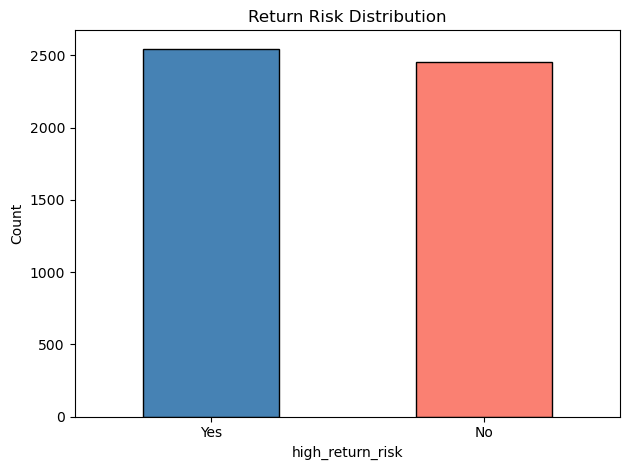

In [5]:
print('Target Distribution:')
print(df['high_return_risk'].value_counts())

df['high_return_risk'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'], edgecolor='black')
plt.title('Return Risk Distribution')
plt.xlabel('high_return_risk')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

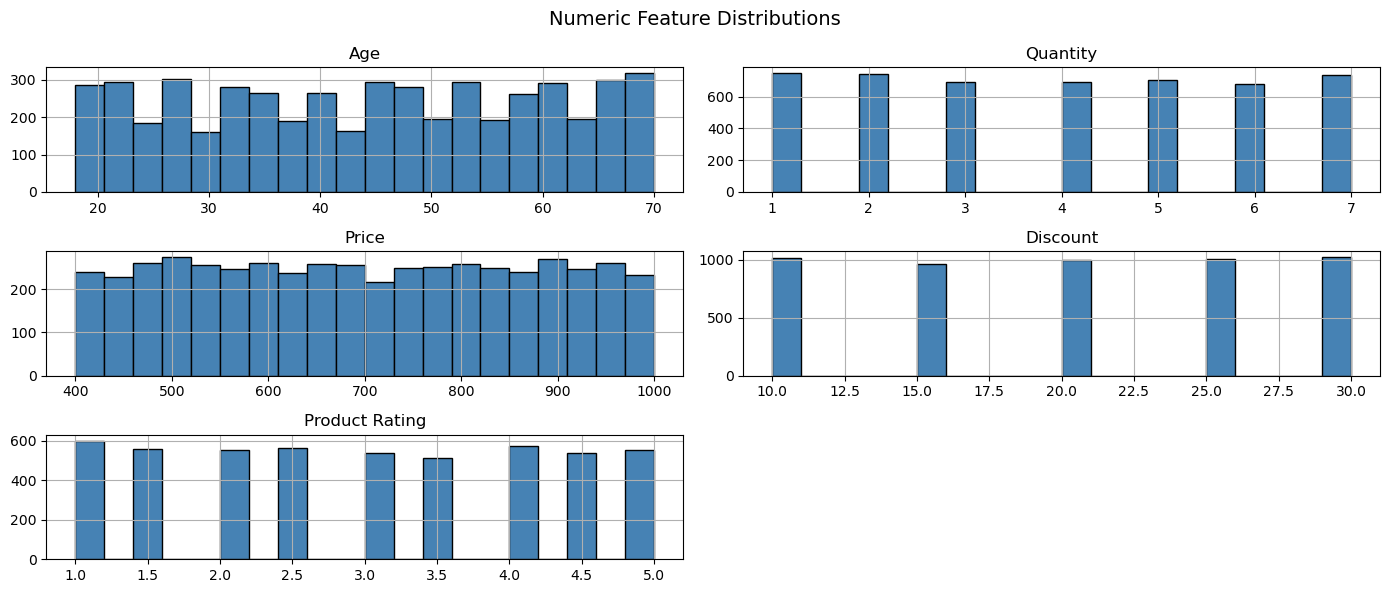

In [6]:
num_cols = ['Age', 'Quantity', 'Price', 'Discount', 'Product Rating']
df[num_cols].hist(bins=20, figsize=(14, 6), color='steelblue', edgecolor='black')
plt.suptitle('Numeric Feature Distributions', fontsize=14)
plt.tight_layout()
plt.show()

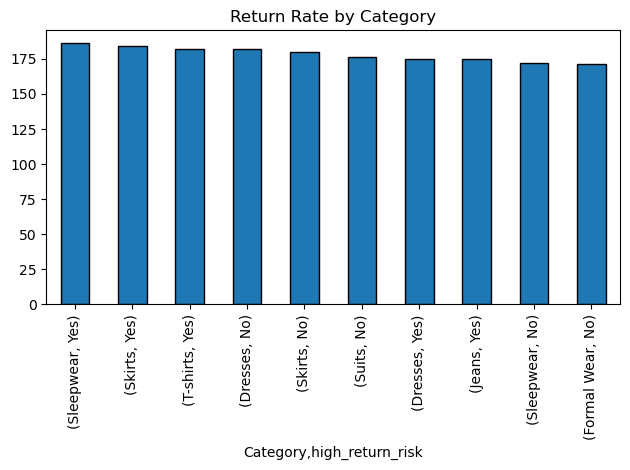

In [7]:
df.groupby('Category')['high_return_risk'].value_counts().sort_values(ascending=False).head(10).plot(kind='bar',edgecolor='black')
plt.title('Return Rate by Category')
plt.tight_layout()
plt.show()

C:\Users\Ekangsh\AppData\Local\Temp\ipykernel_26276\3483070584.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='high_return_risk', y='Price', data=df, palette=['steelblue', 'salmon'])


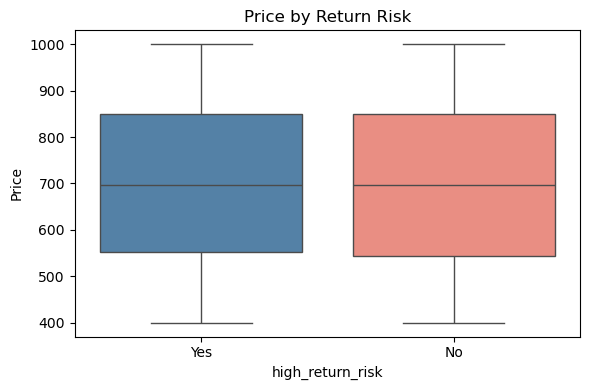

In [8]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='high_return_risk', y='Price', data=df, palette=['steelblue', 'salmon'])
plt.title('Price by Return Risk')
plt.tight_layout()
plt.show()

C:\Users\Ekangsh\AppData\Local\Temp\ipykernel_26276\964458074.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='high_return_risk', y='Discount', data=df, palette=['steelblue', 'salmon'])


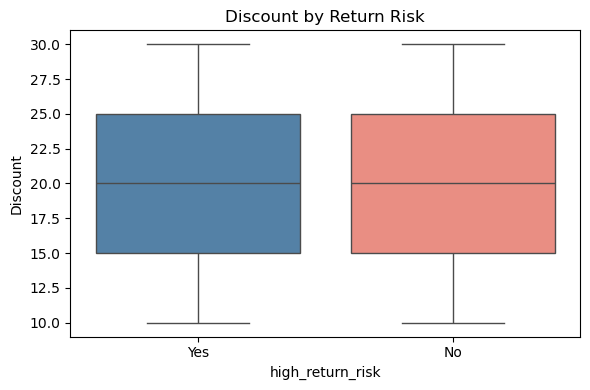

In [9]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='high_return_risk', y='Discount', data=df, palette=['steelblue', 'salmon'])
plt.title('Discount by Return Risk')
plt.tight_layout()
plt.show()

## 4. Preprocessing

In [10]:
df.drop(['Unnamed: 0'], axis=1, inplace=True)

# cat_cols = ['Category', 'State', 'Brand', 'Gender']
# for col in cat_cols:
#     le = LabelEncoder()
#     df[col] = le.fit_transform(df[col])

# le_target = LabelEncoder()
# df['high_return_risk'] = le_target.fit_transform(df['high_return_risk'])

# print('Encoding done. Target classes:', le_target.classes_, '->', le_target.transform(le_target.classes_))
# df.head()

cat_cols = ['Category', 'State', 'Brand', 'Gender']
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

le_target = LabelEncoder()
df['high_return_risk'] = le_target.fit_transform(df['high_return_risk'])

df

,Age,Gender,State,Category,Brand,Quantity,Price,Discount,Product Rating,high_return_risk
0,58,0,7,6,3,5,409,30,1.0,1
1,29,1,25,9,3,3,700,25,1.0,1
2,32,0,14,5,7,2,898,20,3.0,0
3,53,1,1,4,7,6,607,10,3.5,1
4,25,0,5,4,0,5,568,10,1.0,0
...,...,...,...,...,...,...,...,...,...,...
4995,70,0,7,3,0,7,939,15,3.0,0
4996,46,0,18,3,2,6,439,15,2.5,0
4997,56,0,1,8,5,3,730,25,1.5,1
4998,54,1,3,2,6,1,955,15,4.0,1


## 5. Feature & Target Split

In [11]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

print('Features:', list(X.columns))
print('X shape:', X.shape)
print('y shape:', y.shape)

Features: ['Age', 'Gender', 'State', 'Category', 'Brand', 'Quantity', 'Price', 'Discount', 'Product Rating']
X shape: (5000, 9)
y shape: (5000,)


## 6. Train-Test Split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=10, stratify=y
)

print('Train size:', X_train.shape)
print('Test size :', X_test.shape)
X_train


Train size: (4000, 9)
Test size : (1000, 9)


,Age,Gender,State,Category,Brand,Quantity,Price,Discount,Product Rating
1428,40,1,17,1,7,3,548,10,5.0
174,33,1,20,11,3,4,646,25,4.5
4922,21,1,13,6,7,4,724,10,4.0
3353,25,0,0,1,6,1,876,10,5.0
1939,30,1,27,14,0,6,899,15,1.5
...,...,...,...,...,...,...,...,...,...
409,67,0,1,7,4,3,717,10,1.5
2825,70,0,8,13,7,5,683,30,4.5
322,45,1,13,4,7,5,952,10,3.5
4672,33,1,24,2,1,1,847,20,2.0


## 7. Feature Scaling

In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
X_train_scaled


array([[-2.78396425e-01,  1.00300451e+00,  4.08056468e-01, ...,
        -8.82296622e-01, -1.41121654e+00,  1.56669695e+00],
       [-7.30889599e-01,  1.00300451e+00,  7.80172708e-01, ...,
        -3.14380622e-01,  7.06137610e-01,  1.18142781e+00],
       [-1.50659218e+00,  1.00300451e+00, -8.80985200e-02, ...,
         1.37634153e-01, -1.41121654e+00,  7.96158672e-01],
       ...,
       [ 4.48129847e-02,  1.00300451e+00, -8.80985200e-02, ...,
         1.45890811e+00, -1.41121654e+00,  4.10889535e-01],
       [-7.30889599e-01,  1.00300451e+00,  1.27632770e+00, ...,
         8.50426683e-01,  3.52892359e-04, -7.44917877e-01],
       [-1.18338277e+00, -9.97004487e-01, -7.08292254e-01, ...,
        -3.83921357e-01, -7.05431825e-01, -3.59648740e-01]],
      shape=(4000, 9))

## 8. Logistic Regression

In [14]:
model = LogisticRegression(max_iter=1000, random_state=10)
model.fit(X_train_scaled, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,10
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


Fold 1: 0.5413
Fold 2: 0.5100
Fold 3: 0.5162
Fold 4: 0.5325
Fold 5: 0.4925

Mean CV Accuracy: 0.5185
Std Dev         : 0.0171


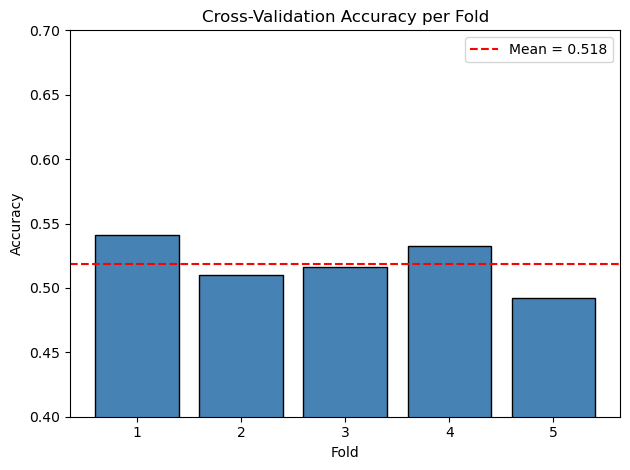

In [15]:
cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')

for i, score in enumerate(cv_scores, 1):
    print(f'Fold {i}: {score:.4f}')

print(f'\nMean CV Accuracy: {cv_scores.mean():.4f}')
print(f'Std Dev         : {cv_scores.std():.4f}')

plt.bar(range(1, 6), cv_scores, color='steelblue', edgecolor='black')
plt.axhline(cv_scores.mean(), color='red', linestyle='--', label=f'Mean = {cv_scores.mean():.3f}')
plt.title('Cross-Validation Accuracy per Fold')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.ylim(0.4, 0.7)
plt.legend()
plt.tight_layout()
plt.show()

## 9. Model Evaluation

In [16]:
y_pred = model.predict(X_test_scaled)

print(f'Test Accuracy : {accuracy_score(y_test, y_pred):.4f}')
print(f'ROC-AUC Score : {roc_auc_score(y_test, y_pred):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['No Risk', 'High Risk']))

Test Accuracy : 0.5010
ROC-AUC Score : 0.4991

              precision    recall  f1-score   support

     No Risk       0.49      0.39      0.43       491
   High Risk       0.51      0.61      0.55       509

    accuracy                           0.50      1000
   macro avg       0.50      0.50      0.49      1000
weighted avg       0.50      0.50      0.50      1000



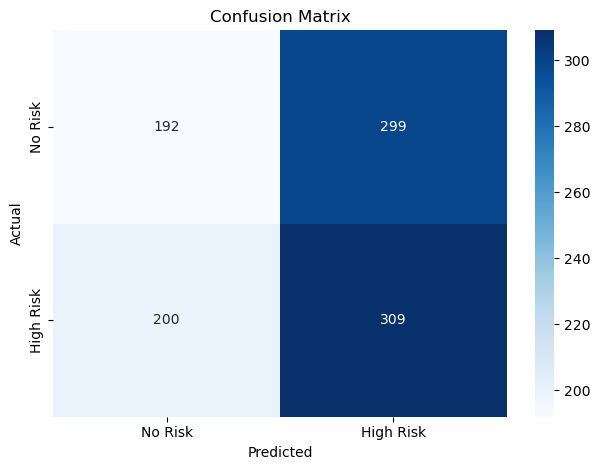

In [17]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Risk', 'High Risk'],
            yticklabels=['No Risk', 'High Risk'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## 10. Feature Importance

       Feature  Coefficient
Product Rating     0.078977
      Discount     0.068923
      Category     0.026058
        Gender     0.020327
         Brand     0.013465
         Price    -0.025585
         State    -0.027736
      Quantity    -0.039108
           Age    -0.050790


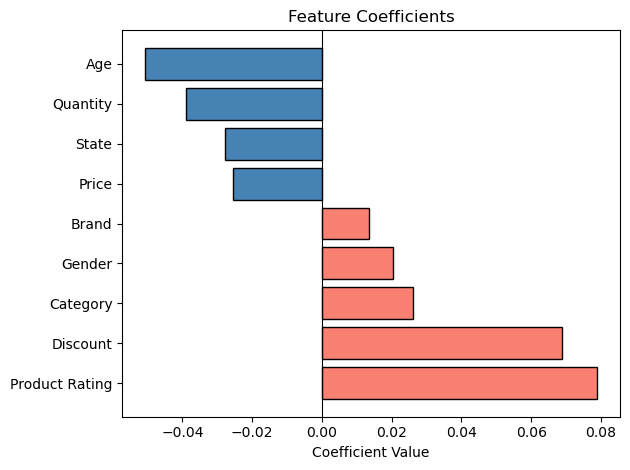

In [18]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient', ascending=False)

print(coef_df.to_string(index=False))

colors = ['salmon' if c > 0 else 'steelblue' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='black')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Coefficients')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

## 11. Key Insights

- **Dataset:** 5,000 purchase records, balanced 50/50 between High Risk and No Risk
- **Model:** Logistic Regression — simple and interpretable
- **Accuracy ~50%:** The model struggles to find a strong pattern. This tells us return behavior is not driven by basic features like Age or Price alone.
- **Business Implication:** Returns may be driven by factors not in the data — product quality, sizing, misleading descriptions.

**Recommendations:**
1. Collect richer data — return reason, delivery time, product reviews
2. Target high-discount categories for return-reduction campaigns
3. Use predictions as a risk-flagging tool before dispatch